# ML04 - Machine Learning Fall 2024

- **Name:** `Mohammad Ali Olama`
- **Student ID:** `####`

---

### Submission Deadline: **December 4th, 2024**
#### Submit your assignment via Microsoft Teams.
#### File Naming Format: `ML04_LASTNAME_STUDENTID.ipynb`

---

### *Instructions for Completing the Problem Set:*

- The problem set includes both coding and written response questions. For coding tasks, complete all code blocks marked with `YOUR CODE HERE`.
  
- For written answers, replace the placeholder text `[Your answer here]`  with your response.

- You are allowed to use AI assistance for this assignment, but you must fully disclose any AI usage in the final cell of this notebook. Please include any prompts you used with AI tools. Failure to disclose AI assistance will result in a zero on the assignment, as we have tools in place to detect such cases. We encourage transparency—there are no restrictions on AI use, so there's no reason not to be honest!

- **(Important Note) : Please do not submit a Colab link for your assignment answers. Instead, make sure to download your work as a `.ipynb` file and attach it directly to your submission. This is essential for proper grading and review.**

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 1: Decision Tree Analysis (20 points)</font>**

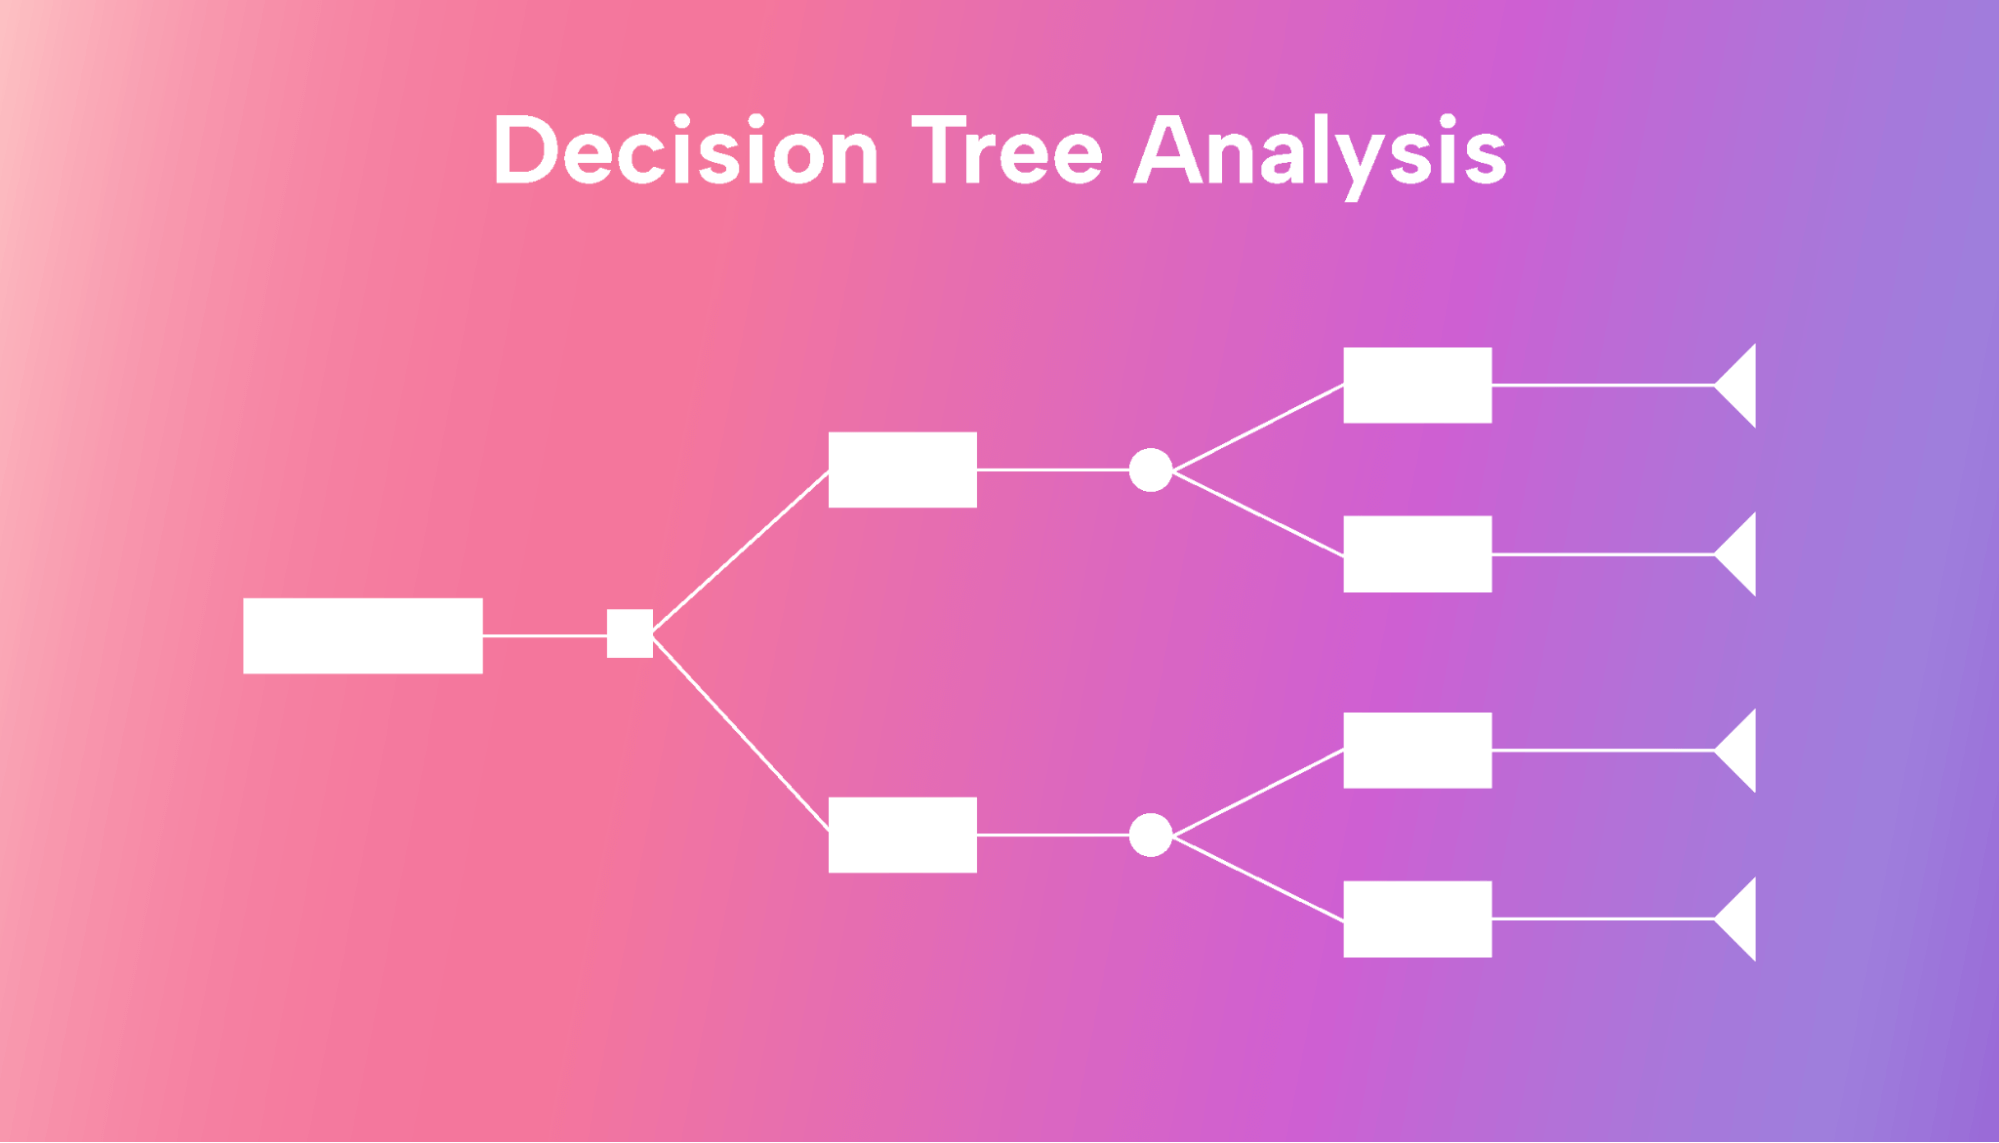

#### <font face="Verdana" color="green" size="+2">**1.1 (3 points)**
Overall, is the Gini Impurity of children greater or less than the parent's? Explain your answer.</font>


In decision tree algorithms like CART (Classification and Regression Trees), the Gini Impurity of children nodes is generally less than or equal to the Gini Impurity of the parent node. This is because the splitting process aims to partition the data such that each child node is more "pure," i.e., has a higher proportion of samples belonging to a single class

#### <font face="Verdana" color="green" size="+2">**1.2 (3 points)**
If a decision tree model is overfitting on the training set, is reducing the max_depth a good idea? Justify your response.</font>

max_depth: This hyperparameter in decision trees controls the maximum depth of the tree, limiting the number of splits and the complexity of the model. A deep tree with a large max_depth can easily overfit the training data because it has more flexibility to create specific rules that capture the nuances and noise in the training set. By limiting the depth of the tree, we constrain its ability to learn extremely specific patterns, forcing it to generalize more. This reduction in complexity helps prevent overfitting and typically improves performance on the test set.

#### <font face="Verdana" color="green" size="+2">**1.3 (3 points)**
If a decision tree model is underfitting, is scaling (normalizing) the input features a good idea? Why or why not?</font>

No, scaling (normalizing) the input features is generally not effective in addressing underfitting in a decision tree model. They use the raw values of features for splitting and are scale-invariant because splitting decisions depend only on relative ordering of data points, not the magnitude of the feature values. To solve underfitting problem, we need to make our model more complex, e.g. by increasing max-depth hyperparameter.



#### <font face="Verdana" color="green" size="+2">**1.4 (3 points)**
If training a decision tree model on a dataset with a specific sample size takes one hour, approximately how much longer will it take if you double the number of input features or samples? Explain your reasoning.</font>

Roughly double the original training time (approximately 2 hours).  The time complexity of training a decision tree is $$ O(d \times n\log n)$$ where $n$ is the number of datapoints and $d$ is the dimension of data. if we double the dimension, then we have $2d$ features which suggest approaximately double training time. On the other hand, doubling the datapoints, will also results in doubling the time. (notice the factor of $\log 2n$ )

#### <font face="Verdana" color="green" size="+2">**1.5 (4 points)**
What is pruning in decision trees? Describe the difference between pre-pruning and post-pruning, and explain how pruning helps improve model performance.</font>

Pruning in decision trees is a technique used to reduce the size of a decision tree by removing parts of the tree that are not critical to its performance. It helps address overfitting, where the tree becomes too complex and starts capturing noise in the training data instead of general patterns. By simplifying the tree, pruning improves its ability to generalize to unseen data.

1. Pre-pruning:
  * Pre-pruning involves stopping the tree's growth during the training phase, before it becomes fully developed. Setting some constraints like max_depth, min_samples_split, ... will results in this kind of pruning, which early stops developing the tree.

  * This one is computationally efficient, as the tree is never allowed to grow excessively. Also it reduces risk of overfitting by controlling tree complexity upfront.
  * But, on the other hand, it has the risk of underfitting if the constraints are too strict. Moreover,it can miss optimal splits that might lead to better performance.

2. Post-pruning:
  * Post-pruning involves growing the tree fully and then removing unnecessary branches or nodes that do not improve the model's performance. The tree is initially grown to its maximum depth (fully expanded). Pruning is performed by evaluating the impact of removing nodes or branches: Nodes are removed if their removal improves a validation metric (e.g., accuracy or a cost-complexity tradeoff).

  * Allows the model to explore all potential splits before deciding which ones are unnecessary. Tends to be more accurate since it considers a fully developed tree.
  * Computationally more expensive than pre-pruning.



How Pruning Helps Improve Model Performance?
1. Reduces Overfitting:

2. Improves Interpretability:

3. Enhances Computational Efficiency:(pre-pruning)

#### <font face="Verdana" color="green" size="+2">**1.6 (4 points)**
What are the key differences in how decision trees are used for classification tasks versus regression tasks? Specifically, explain how predictions are made at the leaf nodes in both tasks.</font>

1. Splitting Criteria:
  * Classification: Nodes are split based on metrics like: Gini Impurity, Entropy/Information Gain, etc. The algorithm seeks to maximize the "purity" of the resulting child nodes by minimizing these impurity measures.
  * Regression: Nodes are split based on criteria like: MSE and MAE. The algorithm seeks to minimize the variance or error of the target values in the child nodes.

2. Predictions at Leaf Nodes
  * Classification: At a leaf node, the predicted class is typically the majority class of the samples that fall into that node. The output is Discrete and categorical (e.g., "spam" vs. "not spam").
  * Regression: At a leaf node, the predicted value is the mean (or sometimes the median) of the target values of the samples in that node. The output is Continuous numerical values (e.g., house price, temperature).

3. Loss function:
  * Classification: Loss functions are based on classification errors, such as cross-entropy or misclassification rate.
  * Regression: Loss functions are based on numerical errors, such as mean squared error (MSE) or mean absolute error (MAE).



<hr>





### **<font face="Courier New" color="blue" size="+3">Question 2: Decision Tree Regressor (10 points)</font>**

In this question, you will work with a sample of size 1000 from a **Bike Sharing dataset**, which contains information on hourly bike rentals in Washington, DC. The dataset includes various features such as weather, season, and rental counts. Your goal is to explore the data, train a **Decision Tree Regressor**, and tune hyperparameters to optimize the model.



#### <font face="Verdana" color="green" size="+2">**2.1 Dataset Cleaning and Exploration (2 points)**

Load a random sample of 1000 rows from the Bike Sharing dataset (`hour.csv`). Display the dataset's shape, column names, and basic statistics. Check for any missing values and address them as needed.</font>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict, train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

In [3]:
# Load the dataset with a random sample of 1000 rows
data = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/HW4/hour.csv', nrows=1000)

# Display basic information about the dataset
print("Shape of the dataset:", data.shape)
print("\nColumn names:", data.columns)

Shape of the dataset: (1000, 17)

Column names: Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [4]:
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1.0,0.0,1.312000,11.753000,0.024000,2.982000,0.646000,1.480000,0.205900,0.213066,0.582480,0.194931,4.921000,53.383000,58.304000
std,288.819436,0.0,0.0,0.463542,6.899101,0.153126,2.091423,0.478448,0.651171,0.078977,0.077790,0.187977,0.129126,7.643899,47.893968,50.985558
min,1.000000,1.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.210000,0.000000,0.000000,0.000000,1.000000
25%,250.750000,1.0,0.0,1.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.160000,0.166700,0.440000,0.104500,0.000000,15.000000,16.000000
50%,500.500000,1.0,0.0,1.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.200000,0.212100,0.550000,0.164200,3.000000,46.000000,49.000000
75%,750.250000,1.0,0.0,2.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.240000,0.257600,0.700000,0.283600,6.000000,74.000000,83.000000
max,1000.000000,1.0,0.0,2.000000,23.000000,1.000000,6.000000,1.000000,4.000000,0.460000,0.454500,1.000000,0.582100,62.000000,247.000000,249.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     1000 non-null   int64  
 1   dteday      1000 non-null   object 
 2   season      1000 non-null   int64  
 3   yr          1000 non-null   int64  
 4   mnth        1000 non-null   int64  
 5   hr          1000 non-null   int64  
 6   holiday     1000 non-null   int64  
 7   weekday     1000 non-null   int64  
 8   workingday  1000 non-null   int64  
 9   weathersit  1000 non-null   int64  
 10  temp        1000 non-null   float64
 11  atemp       1000 non-null   float64
 12  hum         1000 non-null   float64
 13  windspeed   1000 non-null   float64
 14  casual      1000 non-null   int64  
 15  registered  1000 non-null   int64  
 16  cnt         1000 non-null   int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 132.9+ KB


#### <font face="Verdana" color="green" size="+2">**2.2 Train a Base Decision Tree Regressor (3 points)**



In [7]:
# Check for null values in each column
print(data.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


#### <font face="Verdana" color="green" size="+2">**2.2.1**

Set the **total rental count** (`cnt`) as the target variable. Split the data into training and testing sets, then train a **Decision Tree Regressor** with default hyperparameters. Report **Mean Squared Error (MSE)** and **R²** score on both the training and testing sets.</font>

In [8]:
# Set the target variable
y = data['cnt']

# Drop irrelevant columns and the target variable from the features
X = data.drop(['cnt', 'dteday'], axis=1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [9]:
# Initialize and train a Decision Tree Regressor with default parameters
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

# Make predictions on training and testing sets
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)

# Evaluate the model
mse_train = metrics.mean_squared_error(y_train, y_train_pred)
r2_train = metrics.r2_score(y_train, y_train_pred)
mse_test = metrics.mean_squared_error(y_test, y_test_pred)
r2_test = metrics.r2_score(y_test, y_test_pred)

print(f"Training MSE: {mse_train:.10f}")
print(f"Training R^2: {r2_train:.10f}")
print(f"Testing MSE: {mse_test:.10f}")
print(f"Testing R^2: {r2_test:.10f}")

Training MSE: 0.0000000000
Training R^2: 1.0000000000
Testing MSE: 9.1300000000
Testing R^2: 0.9964193635


 #### <font face="Verdana" color="green" size="+2">**2.2.2**
 Analyze the model’s performance on training vs. test sets to determine if it is overfitting or underfitting.</font>

It seems the model is performing excellent on both train and test this, which means no overfitting or underfitting is occured.

#### <font face="Verdana" color="green" size="+2">**2.3 Visualize the Decision Tree (2 points)**
Plot the decision tree to better understand the splits and structure. Limit the tree depth for visualization clarity.</font>


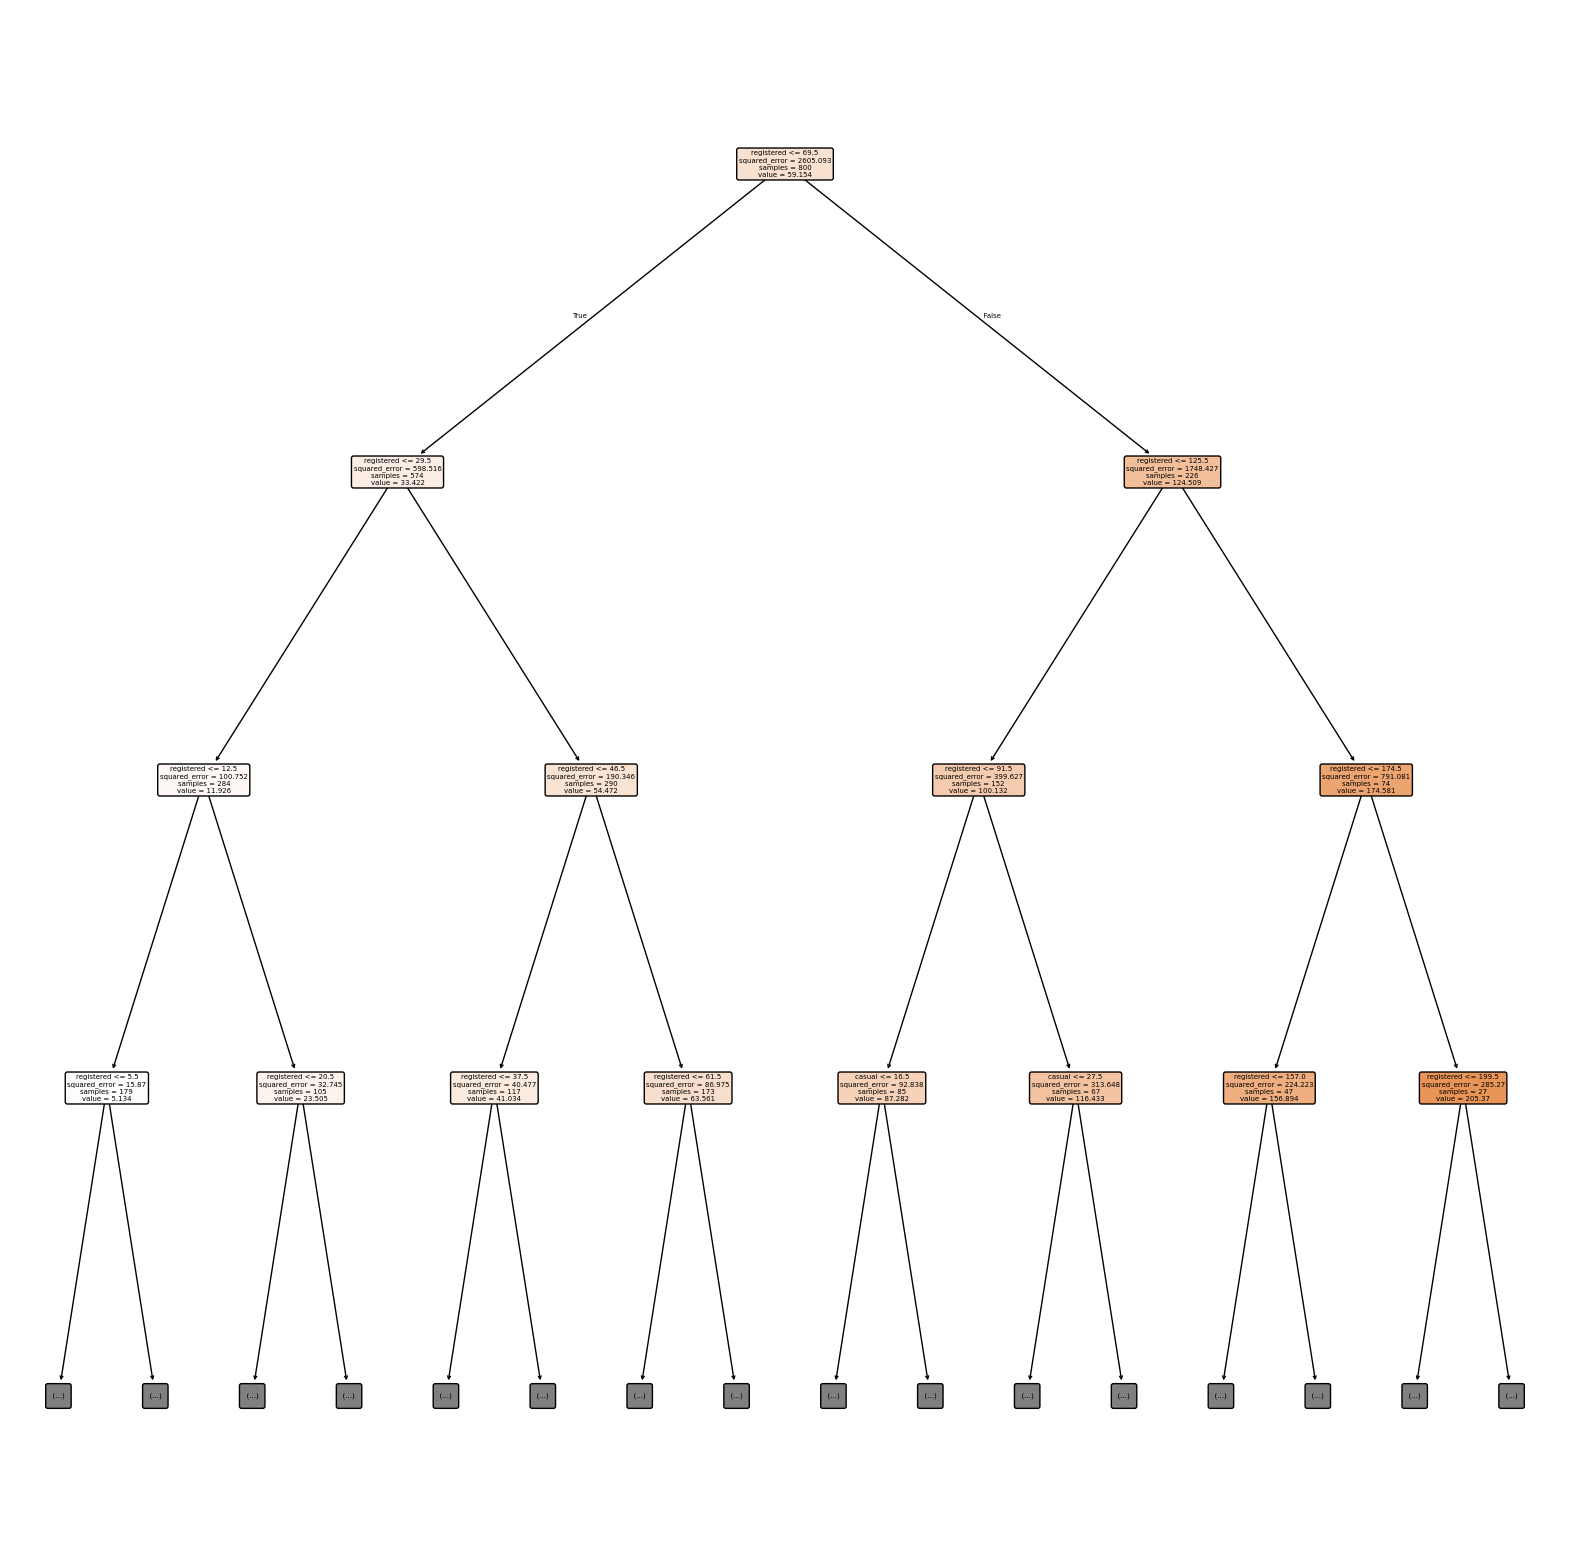

In [10]:
plt.figure(figsize=(20, 20))
plot_tree(dt_regressor, max_depth=3, feature_names=X.columns, filled=True, rounded=True)
plt.show()

#### <font face="Verdana" color="green" size="+2">**2.4 Hyperparameter Tuning using Grid Search (3 points)**



#### <font face="Verdana" color="green" size="+2">**2.4.1**
Use **GridSearchCV** to find the best values for `max_depth` and `min_samples_leaf`. Report the best parameters and their corresponding MSE and R² scores on the test set.</font>


In [11]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Initialize the DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

# Make predictions on the test set using the best estimator
y_test_pred = best_estimator.predict(X_test)

# Calculate MSE and R² on the test set
mse_test = metrics.mean_squared_error(y_test, y_test_pred)
r2_test = metrics.r2_score(y_test, y_test_pred)

# Print the results
print(f"Best hyperparameters: {best_params}")
print(f"Test MSE: {mse_test:.8f}")
print(f"Test R^2: {r2_test:.8f}")

Best hyperparameters: {'max_depth': 10, 'min_samples_leaf': 2}
Test MSE: 8.95930492
Test R^2: 0.99648631


<hr>





### **<font face="Courier New" color="blue" size="+3">Question 3: Cost Complexity Pruning in Decision Trees (25 points)</font>**

Cost complexity pruning is a technique used to reduce the overfitting of decision trees by balancing the complexity of the tree against its accuracy on the training data. This process introduces a parameter, alpha, to penalize more complex trees. In this question, you will learn how cost complexity pruning works and apply it to a dataset, experimenting with different levels of pruning and analyzing the results.

#### <font face="Verdana" color="green" size="+2">**3.1. Understanding Cost Complexity Pruning (5 points)**



#### <font face="Verdana" color="green" size="+2">**3.1.1**
Explain the concept of cost complexity pruning in decision trees and how it works. Why is pruning needed, and how does the alpha parameter affect the pruning process?</font>

Cost complexity pruning simplifies decision trees by balancing accuracy and complexity to prevent overfitting. It minimizes a cost function:

$$ R(T)=Error(T)+α⋅Size(T)$$
where $\alpha$ controls the trade-off between error and tree size.

Why Pruning is Needed:
* Prevents overfitting by removing branches that capture noise.
* Improves interpretability and efficiency.

Role of $\alpha$:

* 𝛼=0No pruning; tree remains large.
* Larger 𝛼: More aggressive pruning, focusing on simplicity over accuracy.

Optimal 𝛼 is chosen via cross-validation to maximize generalization.

#### <font face="Verdana" color="green" size="+2">**3.1.2**
How does pruning help to prevent overfitting in decision trees? What is the balance between tree complexity and model performance?</font>

Pruning helps prevent overfitting in decision trees by removing branches that capture noise or irrelevant details from the training data. It simplifies the tree, making it less likely to memorize the training data, which improves generalization to new, unseen data.

The balance between tree complexity and model performance is crucial:

* Complex trees (with many branches) can perfectly fit the training data, but they may overfit and perform poorly on new data.
* Simplified trees (after pruning) are less likely to overfit and tend to perform better on unseen data by focusing on the most important patterns.

Pruning reduces the tree's complexity (number of nodes and branches) while maintaining sufficient predictive accuracy, ensuring the model generalizes well without overfitting.

#### <font face="Verdana" color="green" size="+2">**3.2. Fitting a Decision Tree Model (5 points)**

#### <font face="Verdana" color="green" size="+2">**3.2.1**
 Load the **Breast Cancer dataset** from the `sklearn` library and split it into training and testing sets.</font>

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()
X, y = breast_cancer.data, breast_cancer.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### <font face="Verdana" color="green" size="+2">**3.2.2**
 Train a decision tree classifier on the dataset using `ccp_alpha=0` (i.e., no pruning). Report the accuracy and other performance metrics on the training and testing sets.</font>

In [14]:
from sklearn.metrics import classification_report

# Initialize and train a Decision Tree Classifier with ccp_alpha=0
dt_classifier = DecisionTreeClassifier(ccp_alpha=0, random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on training and testing sets
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

# Evaluate the model and print classification reports
print("Training Set Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nTesting Set Classification Report:")
print(classification_report(y_test, y_test_pred))

Training Set Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00       286

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455


Testing Set Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



 #### <font face="Verdana" color="green" size="+2">**3.3.  Applying Cost Complexity Pruning (7 points)**

#### <font face="Verdana" color="green" size="+2">**3.3.1**
 Use `cost_complexity_pruning_path` to calculate the effective alpha values for the decision tree. Visualize the relationship between alpha values and the total impurity of the pruned leaves.</font>

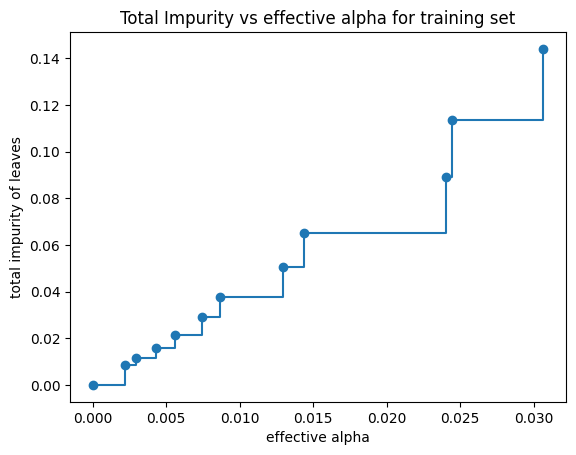

In [15]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

path = dt_classifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

#### <font face="Verdana" color="green" size="+2">**3.3.2**
Train the decision tree using different alpha values and report the training and testing accuracy for each pruned tree. How does accuracy change as the tree becomes more pruned?</font>

Alpha: 0.0000, Training Accuracy: 1.0000, Testing Accuracy: 0.9474
Alpha: 0.0022, Training Accuracy: 0.9956, Testing Accuracy: 0.9474
Alpha: 0.0029, Training Accuracy: 0.9934, Testing Accuracy: 0.9474
Alpha: 0.0043, Training Accuracy: 0.9912, Testing Accuracy: 0.9561
Alpha: 0.0056, Training Accuracy: 0.9890, Testing Accuracy: 0.9561
Alpha: 0.0074, Training Accuracy: 0.9846, Testing Accuracy: 0.9561
Alpha: 0.0087, Training Accuracy: 0.9802, Testing Accuracy: 0.9561
Alpha: 0.0129, Training Accuracy: 0.9670, Testing Accuracy: 0.9561
Alpha: 0.0144, Training Accuracy: 0.9582, Testing Accuracy: 0.9474
Alpha: 0.0240, Training Accuracy: 0.9297, Testing Accuracy: 0.9298
Alpha: 0.0244, Training Accuracy: 0.9231, Testing Accuracy: 0.9123
Alpha: 0.0307, Training Accuracy: 0.9209, Testing Accuracy: 0.8947
Alpha: 0.3229, Training Accuracy: 0.6286, Testing Accuracy: 0.6228


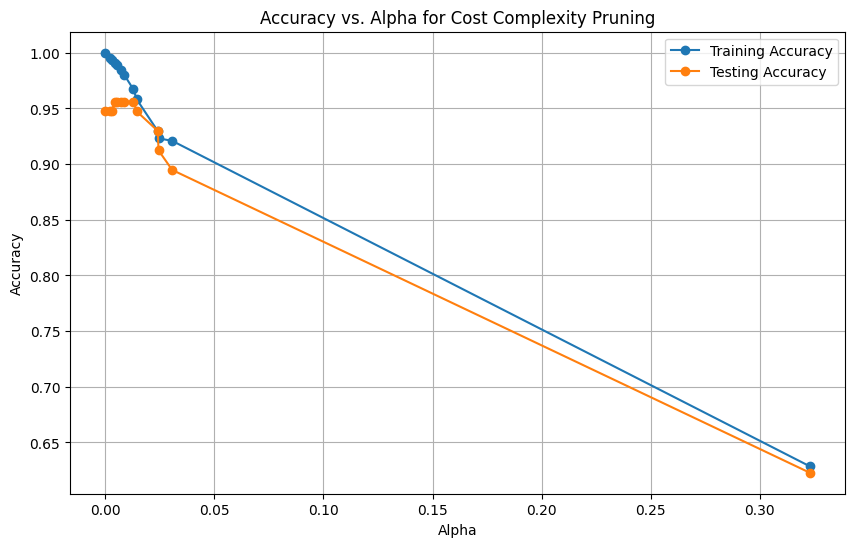

In [16]:

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train the decision tree using different alpha values
train_scores = []
test_scores = []
ccp_alphas = path.ccp_alphas

for ccp_alpha in ccp_alphas:
    dt_classifier = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt_classifier.fit(X_train, y_train)

    y_train_pred = dt_classifier.predict(X_train)
    y_test_pred = dt_classifier.predict(X_test)

    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# Print the results for each alpha value
for i in range(len(ccp_alphas)):
  print(f"Alpha: {ccp_alphas[i]:.4f}, Training Accuracy: {train_scores[i]:.4f}, Testing Accuracy: {test_scores[i]:.4f}")

# Plot the accuracy scores as a function of alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Training Accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Testing Accuracy')
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Alpha for Cost Complexity Pruning")
plt.legend()
plt.grid(True)
plt.show()

#### <font face="Verdana" color="green" size="+2">**3.4. Evaluating Pruned Trees (5 points)**

#### <font face="Verdana" color="green" size="+2">**3.4.1**
For each pruned decision tree, plot how the accuracy changes on the training and testing sets as the alpha value increases.
</font>

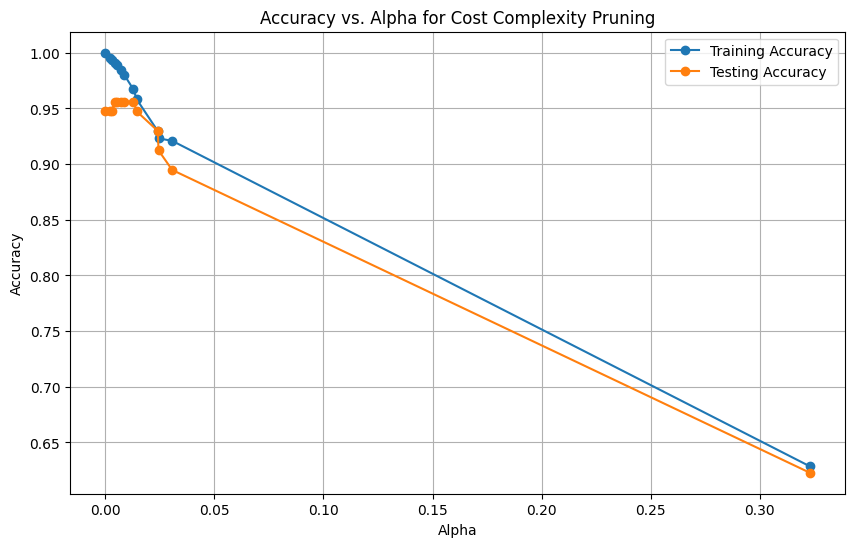

In [17]:

# Plot the accuracy scores as a function of alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Training Accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Testing Accuracy')
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Alpha for Cost Complexity Pruning")
plt.legend()
plt.grid(True)
plt.show()

#### <font face="Verdana" color="green" size="+2">**3.4.2**
 Analyze the accuracy changes and discuss which alpha value provides the best balance between complexity (tree size) and accuracy on the test set.
</font>

In [18]:
best_alpha_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_alpha_index]
best_test_accuracy = test_scores[best_alpha_index]

print(f"\nBest alpha value: {best_alpha:.4f}")
print(f"Corresponding testing accuracy: {best_test_accuracy:.4f}")




Best alpha value: 0.0043
Corresponding testing accuracy: 0.9561


Look for an alpha value where the testing accuracy is high and relatively stable,
and where further increases in alpha don't significantly improve testing accuracy but
lead to a decrease in training accuracy, indicating a reduction in model complexity without
hurting generalization performance.

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 4: Malware Detection using Ensemble Methods (39 points)</font>**

Malware programming is one of the most adversarial ways to earn money, with significant activity observed in 2014 (based on a VirusTotal.com report). Anti-malware programming, in response, aims to mitigate these threats, leveraging both **static behaviors** (e.g., file signature, memory allocation) and **dynamic behaviors** (e.g., network communication, OS API calls).

In this assignment, you are given a custom dataset containing OS API call behaviors with a binary label (`OUTPUT`). Your task is to build anti-malware models using various machine learning and ensemble techniques to compare and evaluate their performance.

**For this part, You will use `anti-malware.csv` dataset.**

In [19]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier

#### <font face="Verdana" color="green" size="+2">**4.1 Evaluating Error Types (4 points)**

In anti-malware applications, minimizing certain types of errors is critical. You will explore which type of error—**False Positive Rate** or **False Negative Rate**—is more impactful for security and user experience.

  

<font face="Verdana" color="green" size="+2">
  Which error is more critical in anti-malware systems: False Positive Rate or False Negative Rate? Why?  
  Consider both security and user experience perspectives in your answer.</font>

<font face="Verdana" color="red" size="+2">**1. Security Perspective**</font>

1. False Negative Rate (FNR): A false negative occurs when the system fails to identify malware and classifies it as benign.

  * Malware remains undetected and can compromise the system, leading to data breaches, financial loss, or damage to infrastructure.
  * Attackers may exploit vulnerabilities without user awareness, potentially leading to widespread harm.

2. False Positive Rate (FPR): A false positive occurs when the system incorrectly identifies a benign file or process as malware.
  * No direct security compromise, but can result in unnecessary quarantining or deletion of harmless files.
  * Can disrupt legitimate operations but does not expose the system to threats.


<font face="Verdana" color="red" size="+2">**2. User Experience Perspective**</font>

1. False Positive Rate (FPR):
  * Legitimate applications or files may be flagged, causing frustration and productivity loss.
  * May result in users losing trust in the anti-malware system, leading them to disable or ignore it entirely.
2. False Negative Rate (FNR):
  * Users are unaware of threats, leading to a false sense of security.
  * If the malware causes visible harm (e.g., data theft or performance issues), users will lose confidence in the system’s effectiveness.


***False Negatives Are Typically More Critical***
The damage caused by undetected malware often outweighs the inconvenience of false positives.


#### <font face="Verdana" color="green" size="+2">**4.2 Stratified Splitting  (4 points)**

You will use **stratified sampling** to ensure class balance in the train-test split, which is particularly important for imbalanced datasets. This also reduces computational cost by dropping half the dataset.  

#### <font face="Verdana" color="green" size="+2">**4.2.1**
  Use stratified sampling to drop %65 of the dataset to reduce computational cost and split the reduced dataset into training (80%) and testing (20%) sets.
</font>

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/HW4/anti-malware.csv')

# Separate features (X) and target (y)
X = data.drop('OUTPUT', axis=1)
y = data['OUTPUT']

# Stratified sampling to reduce dataset size
data_reduced, _, y_reduced, _ = train_test_split(
    X, y, test_size=0.65, stratify=y, random_state=42
)

# Split the reduced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data_reduced, y_reduced, test_size=0.2, stratify=y_reduced, random_state=42
)

#### <font face="Verdana" color="green" size="+2">**4.2.2**
  What is stratified sampling, and why is it important in this context?
</font>

Stratified sampling is a statistical technique where the population is divided into subgroups (strata) based on shared characteristics, and samples are taken proportionally or equally from each stratum.
In a dataset for binary classification, the subgroups (strata) might be the two classes: positive and negative.
If the dataset contains 80% negatives and 20% positives, stratified sampling ensures that any sampled subset maintains this 80-20 ratio.


In the context of anti-malware systems or other machine learning tasks, stratified sampling ensures that the training and testing datasets are representative of the original data distribution. This is particularly important for imbalanced datasets or scenarios where class proportions significantly impact the model's performance.


Without stratification, the test set might contain an unrepresentative class distribution, leading to misleading performance metrics (e.g., artificially low or high accuracy).
Stratification ensures the test set reflects the actual distribution of classes, providing reliable evaluation metrics like precision, recall, and F1-score.



#### <font face="Verdana" color="green" size="+2">**4.2.3**
 How does stratified sampling ensure better model training compared to random splitting?
</font>

Stratified sampling improves model training by maintaining the original class distribution in the training and test datasets, which leads to more reliable learning and evaluation.

* Maintains Class Proportions:
  * Ensures training and test sets preserve the original dataset's class distribution.
  * Prevents bias toward the majority class, especially in imbalanced datasets.

* Handles Imbalanced Data Better:
  * Guarantees minority classes are adequately represented, reducing False Negative Rates (FNR) and improving model learning.

* Produces Reliable Evaluation Metrics:
  * Test sets with proportional class distribution provide meaningful metrics (e.g., precision, recall, F1-score).


#### <font face="Verdana" color="green" size="+2">**4.3 Bagging Classifier  (6 points)**

Bagging improves model stability by training multiple base models on random subsets of data and combining their predictions. You will compare results using different base estimators and ensemble sizes.  

#### <font face="Verdana" color="green" size="+2">**4.3.1**
- Implement a **BaggingClassifier** with **K-NN** as the base estimator.  
- Implement a **BaggingClassifier** with **Decision Tree** as the base estimator.  
- Fine-tune parameters (e.g., number of estimators, K for K-NN, tree depth) to optimize performance.
- Evaluate and compare the models using normalized confusion matrices, recall, accuracy, and ROC curves.
</font>

In [21]:
# KNN
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': [3, 5, 7, 9]}
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5)
grid_search_knn.fit(X_train, y_train)
best_knn = grid_search_knn.best_estimator_

bagging_knn = BaggingClassifier(estimator=best_knn, n_estimators=10, random_state=42)
bagging_knn.fit(X_train, y_train)
y_pred_knn = bagging_knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [None, 5, 10, 15]}
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5)
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

bagging_dt = BaggingClassifier(estimator=best_dt, n_estimators=10, random_state=42)
bagging_dt.fit(X_train, y_train)
y_pred_dt = bagging_dt.predict(X_test)

# Evaluation
print("Bagging with KNN:")
print(classification_report(y_test, y_pred_knn))
print("\nBagging with Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Bagging with KNN:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       168
           1       0.97      0.98      0.97       621

    accuracy                           0.96       789
   macro avg       0.94      0.93      0.93       789
weighted avg       0.96      0.96      0.96       789


Bagging with Decision Tree:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       168
           1       0.97      0.98      0.98       621

    accuracy                           0.96       789
   macro avg       0.95      0.94      0.94       789
weighted avg       0.96      0.96      0.96       789



In [22]:
from sklearn.metrics import confusion_matrix, recall_score, roc_curve, auc
# Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    print(f"--- {model_name} ---")
    print("Confusion Matrix:")
    print(cm)
    print("Normalized Confusion Matrix:")
    print(cm_normalized)
    print(f"Recall: {recall}")
    print(f"Accuracy: {accuracy}")
    print(f"AUC: {roc_auc}")

    plt.figure()
    sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f')
    plt.title(f"Normalized Confusion Matrix for {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic for {model_name}')
    plt.legend(loc="lower right")
    plt.show()

--- Bagging with K-NN ---
Confusion Matrix:
[[148  20]
 [ 15 606]]
Normalized Confusion Matrix:
[[0.88095238 0.11904762]
 [0.02415459 0.97584541]]
Recall: 0.9758454106280193
Accuracy: 0.9556400506970849
AUC: 0.9283988957902001


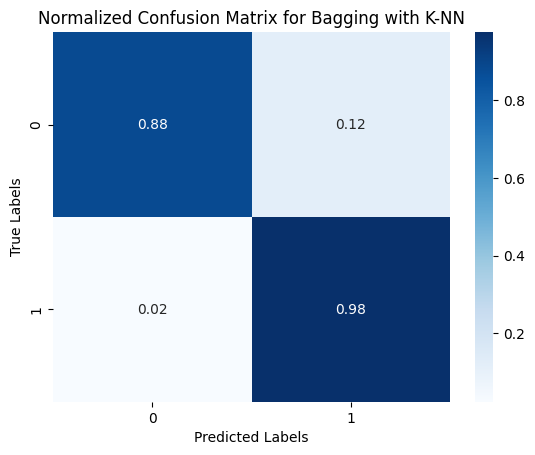

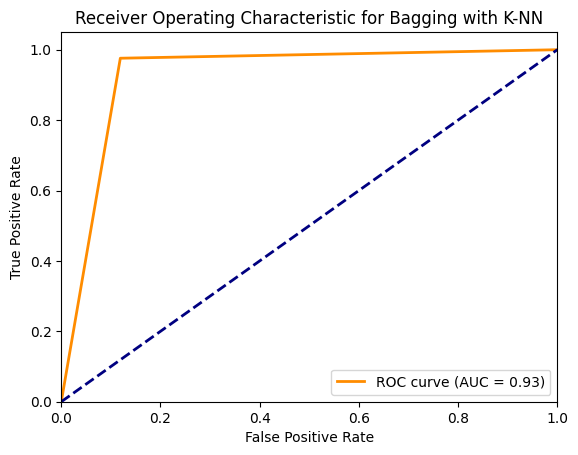

In [23]:

# Evaluate Bagging Classifier with K-NN
evaluate_model(y_test, y_pred_knn, "Bagging with K-NN")



--- Bagging with Decision Tree ---
Confusion Matrix:
[[151  17]
 [ 12 609]]
Normalized Confusion Matrix:
[[0.89880952 0.10119048]
 [0.01932367 0.98067633]]
Recall: 0.9806763285024155
Accuracy: 0.9632446134347274
AUC: 0.9397429261559697


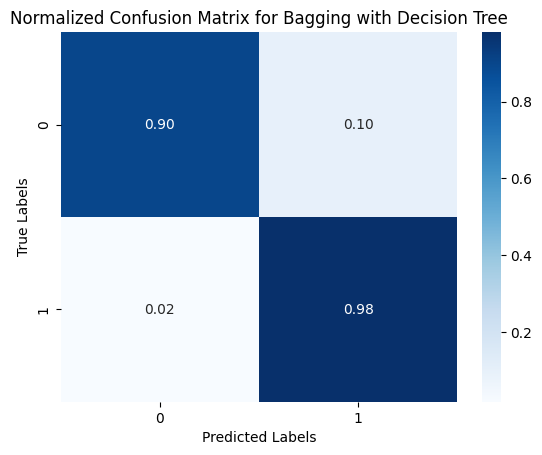

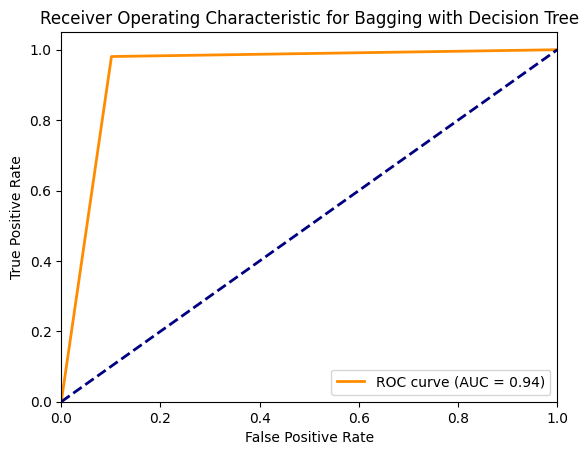

In [24]:
# Evaluate Bagging Classifier with Decision Tree
evaluate_model(y_test, y_pred_dt, "Bagging with Decision Tree")

#### <font face="Verdana" color="green" size="+2">**4.3.2**
- How does Bagging work, and how does it reduce variance?
- Compare the performance of the two Bagging models. Which one is better for malware detection, and why?</font>

Bagging works by training multiple base models on different random subsets of the data (with replacement) and aggregating their predictions (e.g., by voting or averaging). It reduces variance by averaging out errors across multiple models, improving stability and generalization.

KNN vs. DecisionTree in Bagging for Malware Detection:

* KNN may struggle in high-dimensional or large datasets due to its reliance on distance metrics, making it slower and potentially less effective.
* DecisionTree is generally better for malware detection because it handles non-linear relationships and can model complex patterns in the data more effectively. Additionally, decision trees tend to perform better with varied feature types, which is common in malware datasets.

#### <font face="Verdana" color="green" size="+2">**4.4 AdaBoost Classifier  (6 points)**

AdaBoost focuses on misclassified instances by adjusting their weights iteratively, creating a strong model from weak classifiers. You will evaluate its effectiveness using different base estimators.

#### <font face="Verdana" color="green" size="+2">**4.4.1**
- Implement **AdaBoost** with **SVC** as the base estimator.  
- Implement **AdaBoost** with **Decision Tree** as the base estimator.  
- Fine-tune parameters (e.g., number of estimators, learning rate) for both models.  
- Evaluate and compare the models using confusion matrices, recall, accuracy, and ROC curves.
</font>

In [25]:
# # AdaBoost Classifier with SVC
# svc = SVC(probability=True, kernel='rbf') # You might need to adjust kernel and other parameters
# adaboost_svc = AdaBoostClassifier(estimator=svc, n_estimators=50, learning_rate=1.0, random_state=42 , algorithm='SAMME') #Tune n_estimators and learning_rate
# adaboost_svc.fit(X_train, y_train)
# y_pred_svc = adaboost_svc.predict(X_test)
# evaluate_model(y_test, y_pred_svc, "AdaBoost with SVC")

In [26]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


# Create the AdaBoost classifier with DecisionTreeClassifier as the base estimator
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2))

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 70,100],
    'learning_rate': [0.01, 0.1, 1.0],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=ada_clf, param_grid=param_grid, cv=3, scoring='accuracy')

# Fit the GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

# Print the best parameters
print(f"Best hyperparameters: {best_params}")

# Evaluate the best model on the test set
test_accuracy = best_estimator.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

Best hyperparameters: {'learning_rate': 1.0, 'n_estimators': 100}
Test Accuracy: 0.9619771863117871


--- AdaBoost with Decision Tree ---
Confusion Matrix:
[[151  17]
 [ 13 608]]
Normalized Confusion Matrix:
[[0.89880952 0.10119048]
 [0.02093398 0.97906602]]
Recall: 0.9790660225442834
Accuracy: 0.9619771863117871
AUC: 0.9389377731769036


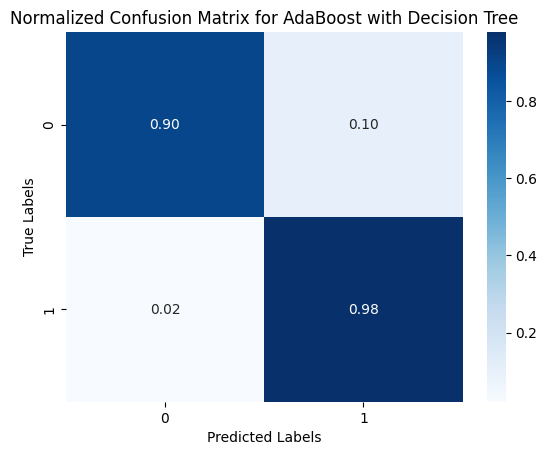

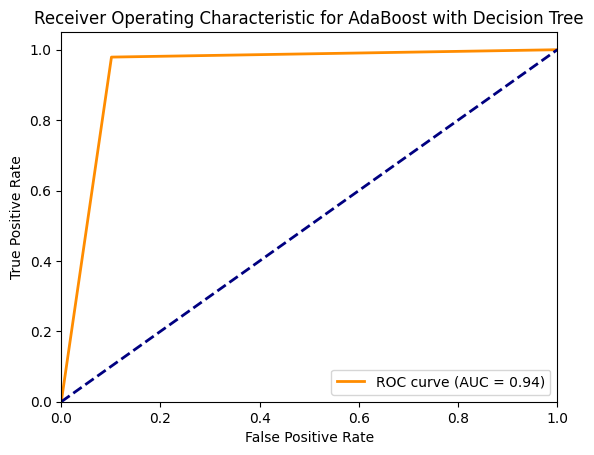

In [27]:
evaluate_model(y_test, best_estimator.predict(X_test), "AdaBoost with Decision Tree")

#### <font face="Verdana" color="green" size="+2">**4.4.2**
- How does AdaBoost handle misclassified instances, and why is this method effective?  
- Compare AdaBoost's performance with Bagging for malware detection. Which method performed better, and why?</font>

Misclassification Handling: During each iteration, AdaBoost assigns a higher weight to the instances that were misclassified by the previous classifier. This forces the next weak classifier to pay more attention to these difficult-to-classify instances, aiming to reduce the overall error in the ensemble.

Effectiveness: This method is effective because it dynamically adjusts the focus of each classifier in the ensemble based on past mistakes. By combining multiple weak classifiers in this adaptive way, AdaBoost can often outperform individual classifiers, especially when the weak learners are simple models (like decision stumps). The iterative focus on hard-to-classify examples helps improve the model's generalization ability, making it robust against overfitting.




Bagging (Bootstrap Aggregating): Bagging works by training multiple independent models on random subsets of the training data (with replacement). Each model is trained independently, and the final prediction is made by averaging the outputs of all the models (for regression) or using a majority vote (for classification). Bagging reduces variance by averaging out errors, and it tends to be most effective when the base models are high-variance models, such as decision trees.

AdaBoost: As described, AdaBoost focuses on correcting misclassified instances from previous models, making it an adaptive method. It tends to reduce both bias and variance, as the algorithm focuses on hard-to-classify instances and gives more weight to them in subsequent iterations. AdaBoost can outperform Bagging in cases where there are complex relationships in the data that require a targeted approach to minimize bias.

In general, AdaBoost may perform better in malware detection if the dataset contains complex patterns that require focusing on difficult-to-classify examples. This is especially true when there is a significant class imbalance (e.g., many benign samples and fewer malware samples), as AdaBoost's iterative focus on misclassified instances could lead to better sensitivity to the malware class.

On the other hand, Bagging might outperform AdaBoost in scenarios where:

The dataset contains noisy or mislabeled data, as Bagging is less sensitive to such issues due to its focus on averaging the predictions of multiple models.
The base models are relatively high-variance, such as decision trees. Bagging can help reduce overfitting and improve stability in these cases.
In practice, Bagging (e.g., Random Forest) is often favored in malware detection tasks due to its stability and ability to handle noisy data, while AdaBoost might shine when the data is well-prepared, and the goal is to reduce bias and emphasize difficult-to-detect instances.

#### <font face="Verdana" color="green" size="+2">**4.5 Generating Multiple Datasets  (3 points)**

To train diverse weak classifiers, you will generate 100 datasets, each containing 5% of the training data, using **replacement** and **stratified sampling**.

#### <font face="Verdana" color="green" size="+2">**4.5.1**
Create 100 datasets, each consisting of 5% of the original training set, using stratified sampling with replacement.
</font>

In [28]:
from sklearn.model_selection import train_test_split

datasets = []
for i in range(100):
    X_sample, _, y_sample, _ = train_test_split(
        X_train, y_train, train_size=0.05, stratify=y_train, random_state=i
    )
    datasets.append((X_sample, y_sample))

#### <font face="Verdana" color="green" size="+2">**4.5.2**
- Why is generating multiple datasets important for training weak classifiers?  
- How does stratified sampling ensure meaningful diversity among datasets?
</font>

Generating multiple datasets for training weak classifiers promotes diversity, reduces overfitting, stabilizes performance, and improves ensemble accuracy. Stratified sampling ensures meaningful diversity by maintaining class proportions in each subset, preventing bias toward majority classes and enabling robust learning across all data types.

#### <font face="Verdana" color="green" size="+2">**4.6 Training Weak Models  (4 points)**

Weak classifiers are crucial for ensemble methods. You will train a variety of weak models on the datasets generated in Part (e).

#### <font face="Verdana" color="green" size="+2">**4.6.1**
Train 55 Decision Trees, 20 SVCs, 15 Multinomial Naive Bayes classifiers, 5 K-NNs, and 5 Logistic Regression models using the datasets from Part (e).  
</font>

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

# Initialize lists to store trained models
decision_trees = []
svcs = []
naive_bayes_classifiers = []
k_nns = []
logistic_regressions = []


# Train Decision Trees
for i in range(55):
  X_sample, y_sample = datasets[i]
  tree = DecisionTreeClassifier(max_depth=2, random_state=i) # You can change max_depth
  tree.fit(X_sample, y_sample)
  decision_trees.append(tree)

# Train SVCs
for i in range(20):
  X_sample, y_sample = datasets[i + 55]
  svc = SVC(probability=True, kernel='rbf', random_state=i) # You might need to adjust kernel and other parameters
  svc.fit(X_sample, y_sample)
  svcs.append(svc)

# Train Multinomial Naive Bayes classifiers
for i in range(15):
    X_sample, y_sample = datasets[i + 75]
    nb = MultinomialNB()
    nb.fit(X_sample, y_sample)
    naive_bayes_classifiers.append(nb)

# Train K-NNs
for i in range(5):
    X_sample, y_sample = datasets[i + 90]
    knn = KNeighborsClassifier(n_neighbors=3) # You can tune n_neighbors
    knn.fit(X_sample, y_sample)
    k_nns.append(knn)

# Train Logistic Regressions
for i in range(5):
    X_sample, y_sample = datasets[i + 95]
    lr = LogisticRegression(random_state=i)
    lr.fit(X_sample, y_sample)
    logistic_regressions.append(lr)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

#### <font face="Verdana" color="green" size="+2">**4.6.2**
- Why are weak classifiers essential for ensemble learning?  
- Discuss the role of diversity among weak classifiers in improving ensemble performance.
</font>

Weak classifiers are essential for ensemble learning because they are simple models that individually perform slightly better than random guessing, but when combined, they create a powerful and accurate model. Diversity among weak classifiers ensures they make different errors, and combining their predictions reduces overall bias and variance, significantly improving ensemble performance.








#### <font face="Verdana" color="green" size="+2">**4.7 Creating a Binary Dataset (4 points)**

You will aggregate predictions from weak models into a binary dataset for meta-model training, simulating a weighted Bagging approach.

#### <font face="Verdana" color="green" size="+2">**4.7.1**
- Pass each sample (both train and test) through the 100 weak models to generate a 100-dimensional prediction vector for each sample.  
- Combine the prediction vector with the original label to create a 101-column dataset (100 predictions + label).
</font>

In [30]:
import pandas as pd
import numpy as np


def create_prediction_dataset(X, models):

    predictions = []
    for model in models:
      try:
        # Predict probabilities for classification models.
        pred = model.predict_proba(X)[:, 1] # Probability of positive class
      except AttributeError:  # For models without predict_proba
        pred = model.predict(X)
      predictions.append(pred)
    return np.column_stack(predictions)


# Concatenate all model lists into one list
all_models = decision_trees + svcs + naive_bayes_classifiers + k_nns + logistic_regressions

# Generate prediction vectors for training and testing datasets
train_predictions = create_prediction_dataset(X_train, all_models)
test_predictions = create_prediction_dataset(X_test, all_models)

# Create the training and testing datasets with labels
train_dataset = np.column_stack((train_predictions, y_train))
test_dataset = np.column_stack((test_predictions, y_test))


# Convert to DataFrames (optional)
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)

# Print or save the datasets (optional)
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,0.034483,0.000000,0.076923,0.103448,0.096774,0.085714,0.064516,0.066667,0.035714,0.038462,...,0.0,0.0,0.0,0.000000,0.09902,9.749434e-03,1.524457e-02,0.33995,0.081998,0.0
1,0.034483,0.000000,0.076923,0.103448,0.096774,0.085714,0.064516,0.066667,0.035714,0.038462,...,0.0,0.0,0.0,0.000000,0.09902,9.749434e-03,1.524457e-02,0.33995,0.081998,0.0
2,0.982759,0.967742,0.989474,1.000000,0.967742,1.000000,0.975410,0.975000,0.960000,0.959350,...,1.0,1.0,1.0,1.000000,1.00000,5.425667e-06,1.000000e+00,1.00000,1.000000,1.0
3,0.982759,0.967742,0.989474,1.000000,0.967742,1.000000,0.975410,0.975000,0.960000,0.959350,...,1.0,1.0,1.0,1.000000,1.00000,1.000000e+00,1.000000e+00,1.00000,1.000000,1.0
4,0.982759,0.967742,0.757576,0.695652,0.967742,1.000000,0.975410,0.975000,0.960000,0.959350,...,1.0,1.0,1.0,0.666667,1.00000,2.603015e-13,5.582154e-80,1.00000,1.000000,0.0


#### <font face="Verdana" color="green" size="+2">**4.7.2**
- How does aggregating predictions from weak models help in training a stronger meta-model?  
- How does this approach differ from traditional Bagging?
</font>


Aggregating predictions from weak models trains a stronger meta-model by leveraging the diverse strengths of individual models. The meta-model learns to combine these predictions in a way that minimizes errors and improves overall accuracy and robustness. This approach captures complex relationships that individual models might miss.

Unlike Bagging, which reduces variance by averaging or voting on predictions independently, stacking uses a meta-model to strategically integrate the predictions, optimizing how they contribute to the final output. This makes stacking more focused on improving predictive performance rather than just reducing variability.

#### <font face="Verdana" color="green" size="+2">**4.8  Training the Meta-Model  (4 points)**

Using the aggregated binary dataset, you will train a **meta-model** to combine predictions from weak classifiers and compare its performance to Bagging and AdaBoost.

#### <font face="Verdana" color="green" size="+2">**4.8.1**
- Train an **SVC** meta-model using the aggregated dataset.  
- Train a **Logistic Regression** meta-model using the aggregated dataset.  
- Evaluate both models on the test set with normalized confusion matrices, recall, accuracy, and ROC curves.  
</font>

In [31]:
# Separate features (X) and labels (y) for meta-models
X_train_meta = train_dataset[:, :-1]
y_train_meta = train_dataset[:, -1].astype(int) # Convert to integer type

X_test_meta = test_dataset[:, :-1]
y_test_meta = test_dataset[:, -1].astype(int) # Convert to integer type


# Train SVC meta-model
svc_meta = SVC(probability=True, kernel='rbf', random_state=42) # You can tune hyperparameters
svc_meta.fit(X_train_meta, y_train_meta)
y_pred_svc_meta = svc_meta.predict(X_test_meta)


# Train Logistic Regression meta-model
lr_meta = LogisticRegression(random_state=42) # You can tune hyperparameters
lr_meta.fit(X_train_meta, y_train_meta)
y_pred_lr_meta = lr_meta.predict(X_test_meta)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- SVC Meta-Model ---
Confusion Matrix:
[[147  21]
 [ 17 604]]
Normalized Confusion Matrix:
[[0.875     0.125    ]
 [0.0273752 0.9726248]]
Recall: 0.9726247987117552
Accuracy: 0.9518377693282636
AUC: 0.9238123993558776


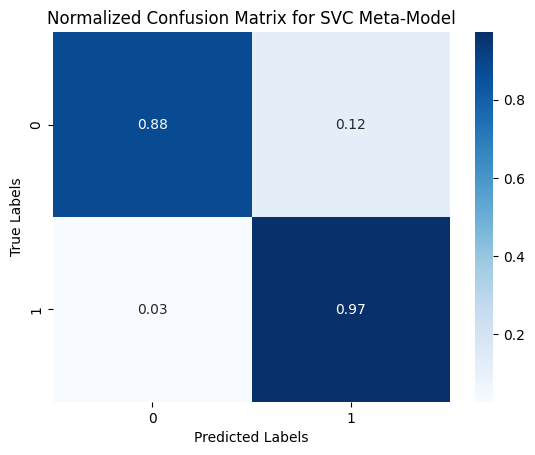

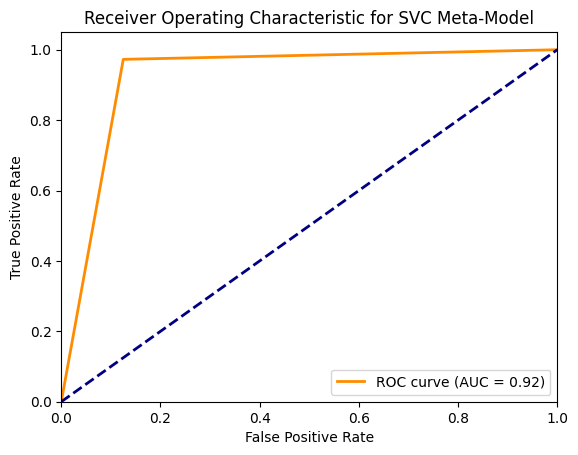

In [32]:

# Evaluate meta-models
evaluate_model(y_test_meta, y_pred_svc_meta, "SVC Meta-Model")


--- Logistic Regression Meta-Model ---
Confusion Matrix:
[[146  22]
 [ 18 603]]
Normalized Confusion Matrix:
[[0.86904762 0.13095238]
 [0.02898551 0.97101449]]
Recall: 0.9710144927536232
Accuracy: 0.9493029150823827
AUC: 0.9200310559006212


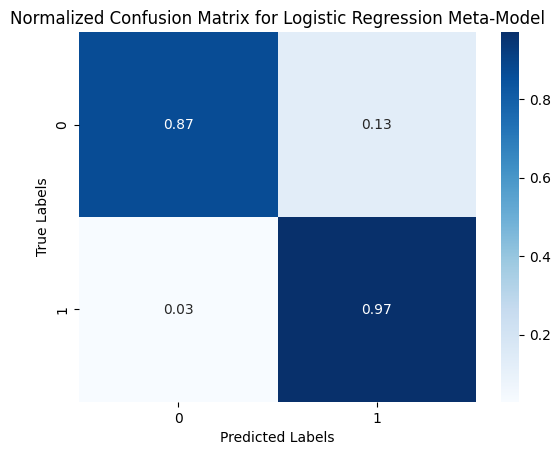

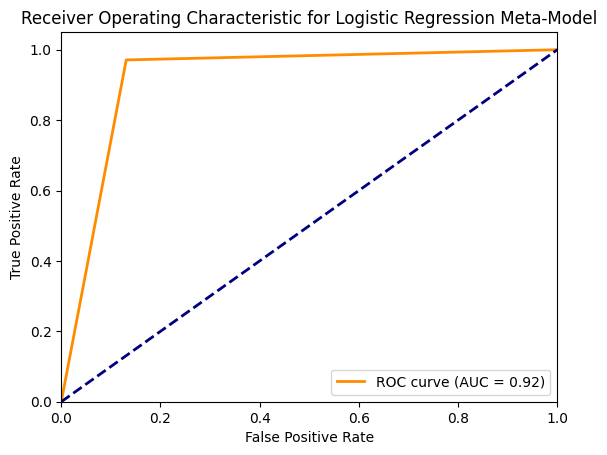

In [33]:
evaluate_model(y_test_meta, y_pred_lr_meta, "Logistic Regression Meta-Model")

#### <font face="Verdana" color="green" size="+2">**4.8.2**
- Compare the meta-model's performance with Bagging and AdaBoost.  
- Which approach performed better for malware detection, and why?
</font>

bagging performs better in terms of accuracy and AUC.

#### <font face="Verdana" color="green" size="+2">**4.9  Stacking Classifier  (4 points)**

Stacking combines predictions from multiple base models using a meta-learner, offering a more sophisticated aggregation method. You will compare its performance to other ensemble methods.

#### <font face="Verdana" color="green" size="+2">**4.9.1**
- Implement a **StackingClassifier** using type of the weak models from Part (f) as base estimators and **Logistic Regression** as the meta-learner.  
- Evaluate the model using confusion matrices, recall, accuracy, and ROC curves.  
</font>

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

--- Stacking Classifier ---
Confusion Matrix:
[[145  23]
 [ 14 607]]
Normalized Confusion Matrix:
[[0.86309524 0.13690476]
 [0.02254428 0.97745572]]
Recall: 0.9774557165861514
Accuracy: 0.9531051964512041
AUC: 0.9202754773406947


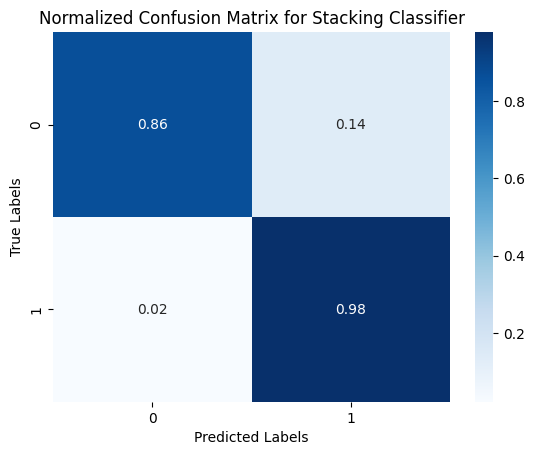

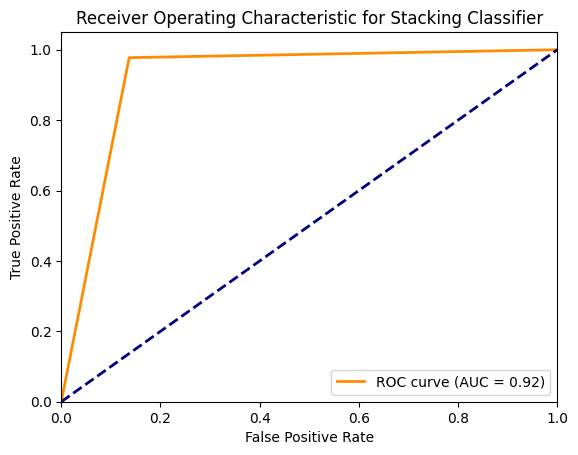

In [34]:
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=2)),
    ('svc', SVC(probability=True, kernel='rbf')),
    ('nb', MultinomialNB()),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
    ('lr', LogisticRegression())
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

evaluate_model(y_test, y_pred_stacking, "Stacking Classifier")

#### <font face="Verdana" color="green" size="+2">**4.9.2**
- How does Stacking differ from Bagging and AdaBoost?  
- Why is the meta-learner critical in the Stacking method?  
- Compare the performance of the StackingClassifier with the meta-model and other ensemble methods.
</font>

How does Stacking differ from Bagging and AdaBoost?
Stacking combines predictions using a meta-model, while Bagging averages/votes for variance reduction, and AdaBoost adjusts weights iteratively to focus on misclassified instances.

Why is the meta-learner critical in the Stacking method?
The meta-learner optimally combines predictions from base models, leveraging their strengths and addressing weaknesses to improve overall performance.

Compare the performance of the StackingClassifier with the meta-model and other ensemble methods.
The StackingClassifier often outperforms other methods by capturing complex relationships, but performance depends on the quality of base models and the meta-learner's design.

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 5: Ensembling Methods (6 points)</font>**

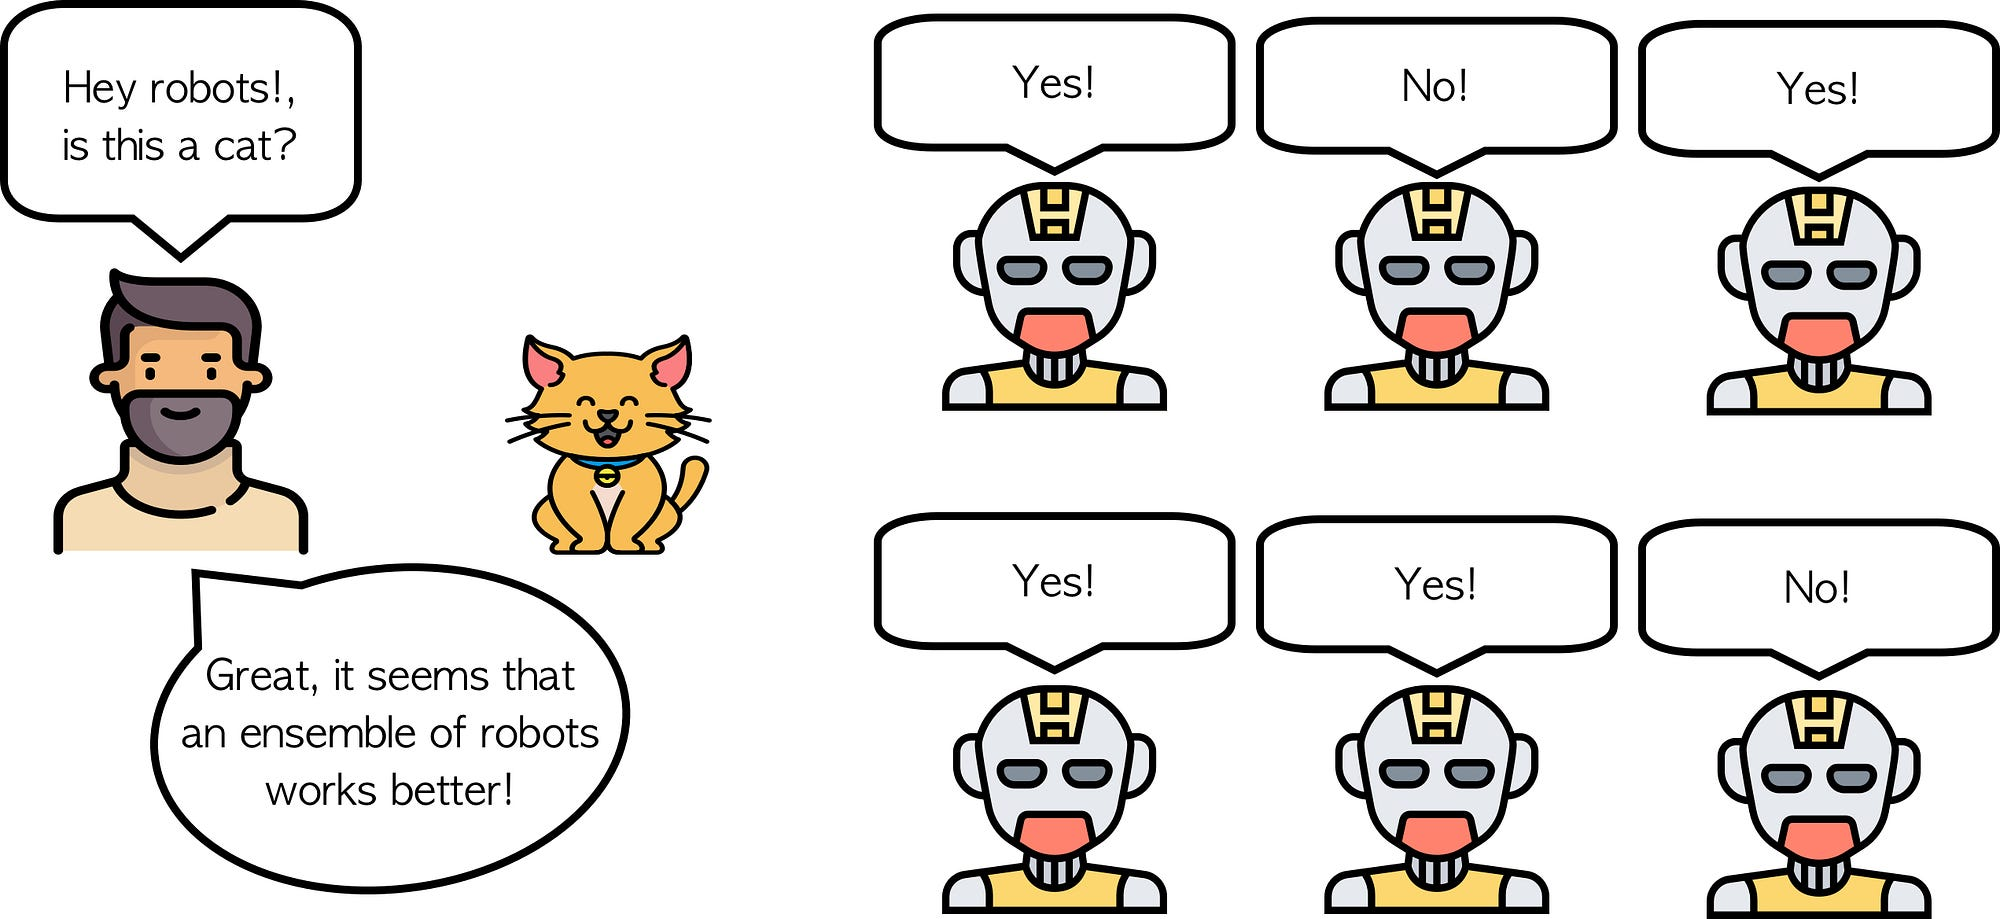

#### <font face="Verdana" color="green" size="+2">**5.1 Voting Classifiers**
- What is a Voting Classifier, and how does it aggregate predictions?  
- Why is the choice of base models critical for a Voting Classifier?
</font>

A Voting Classifier is an ensemble learning method used in machine learning for classification tasks. It combines predictions from multiple base models (also called estimators) to make a final prediction. The idea is that aggregating predictions from diverse models can improve overall accuracy and robustness compared to any single model.

There are two main types of voting strategies for aggregating predictions:
1. Hard Voting:
  * The Voting Classifier predicts the class that receives the majority vote from the base models.

2. Soft Voting:
  * The Voting Classifier predicts the class with the highest average predicted probability across the base models.
Requires the base models to support probability estimates (e.g., ```predict_proba```).


The performance of a Voting Classifier depends heavily on the diversity and quality of the base models.
  * Models should have different strengths and weaknesses to provide complementary predictions.
    * If all models are highly similar (e.g., same algorithm trained on identical features), they may make the same errors, reducing the benefit of voting.
  * Each model should be reasonably accurate. Voting amplifies the strengths of base models but also averages their weaknesses.
    * Including poorly performing models can dilute the performance of the ensemble.
  *

#### <font face="Verdana" color="green" size="+2">**5.2 Pasting**
- What is a Voting Classifier, and how does it aggregate predictions?  
- Under what scenarios might Pasting perform better than Bagging, and vice versa?
- Why is randomness important in these techniques?
</font>

Pasting involves creating multiple subsets of the training data by sampling ***without replacement***.
Each subset is then used to train a separate model, and the predictions from all models are aggregated (e.g., by voting for classification or averaging for regression) to make a final prediction.


 How Pasting Works

1. Subsetting the Data:
Create
$k$ subsets of the training dataset.
Each subset contains a random fraction of the original dataset, sampled without replacement.

2. Training Base Estimators:
Train $k$ separate base models (e.g., decision trees, SVMs) on each subset.

3. Aggregating Predictions:

  * For classification:
Use hard voting (majority class prediction) or soft voting (average probabilities).
  * For regression:
Use averaging to combine predictions from the models.


**Scenarios Where Pasting Performs Better Than Bagging**
1. Large Datasets:
  * When the dataset is large, sampling without replacement (Pasting) ensures efficient use of the data, as it avoids duplicate samples in subsets.
  * The lack of duplicates ensures each model learns from a wider variety of unique data.
2. High Redundancy in the Data:
  * For datasets where samples are similar or repetitive (e.g., many identical or near-identical rows), Pasting avoids over-representing redundant samples, which could happen in Bagging due to replacement.

**Scenarios Where Bagging Performs Better Than Pasting**
1. Small Datasets:
  * In small datasets, Bagging's sampling with replacement ensures sufficient randomness by creating overlapping subsets.
This increases diversity among the base models, reducing overfitting and improving generalization

2. Noisy Data:
  * Bagging is better suited for noisy datasets because the overlap in subsets adds randomness that helps base models avoid learning noise patterns repeatedly. By averaging predictions, Bagging can reduce the impact of noisy samples.



**Importance of Randomness in Pasting and Bagging**
1. Randomness ensures that each base model is trained on a slightly different subset of data, creating diversity in their predictions. Diverse models reduce the risk of overfitting to specific patterns in the training data.
2. When base models make uncorrelated errors due to randomness in training, these errors tend to cancel out during aggregation (e.g., voting or averaging). This improves the ensemble's overall performance and robustness.
3. In high-dimensional or noisy datasets, randomness prevents the base models from learning spurious correlations or noise in the data, Preventing **Overfitting**.



#### <font face="Verdana" color="green" size="+2">**5.3 Gradient Boosting**
- What is Gradient Boosting, and how does it differ from AdaBoost?  
- How does Gradient Boosting handle overfitting?
</font>

#### <font face="Verdana" color="red" size="+2">**Gradient Boosting**
Gradient Boosting is an ensemble learning technique that builds a strong predictive model by combining the outputs of multiple weaker models (usually decision trees) in a **sequential** manner. It is widely used for both classification and regression tasks.

Gradient Boosting works by iteratively improving a model based on the errors (residuals) made by previous models.

* At each iteration:
  * A new weak learner is trained to correct the residuals of the combined model so far.
  * The new model is added to the ensemble with a weight that minimizes the overall loss function.

The term "gradient" comes from the fact that this process optimizes the model by following the gradient of the loss function with respect to the predictions.

#### <font face="Verdana" color="red" size="+2">**AdaBoost**

* Initialize Sample Weights:
  * Start with all training samples assigned equal weights.

* Train a Weak Learner:
  * Train the first weak learner (e.g., a decision stump) on the dataset.

* Calculate Errors:
  * Evaluate the performance of the weak learner.
Misclassified samples are given higher weights, while correctly classified samples are given lower weights.

* Update Sample Weights:
  * Increase the weights of misclassified samples so that the next weak learner focuses more on these "hard-to-classify" examples.

* Combine Weak Learners:
  * Assign each weak learner a weight based on its accuracy. More accurate learners are given higher weights in the final prediction.

* Repeat:
  * Train another weak learner on the updated dataset.
Repeat this process for a specified number of iterations or until the error reaches an acceptable threshold.

* Final Prediction:
  * Combine the predictions of all the weak learners using a weighted majority vote (for classification) or weighted average (for regression).


#### <font face="Verdana" color="red" size="+1">**How Does Gradient Boosting Handle Overfitting?**

* Learning Rate:
  * A smaller learning rate ($η$) slows down the contribution of each weak learner, preventing overfitting. Lower learning rates require more iterations but lead to better generalization.

* Tree Depth:
  * Limit the depth of the trees (```max_depth```) to ensure that each weak learner captures simple patterns rather than overfitting the data.

* Number of Trees:
  * Control the number of trees (```n_estimators```). Too many trees can lead to overfitting, while too few can underfit the data.
